<a href="https://colab.research.google.com/github/Pedrogui29/TP547--Principios-de-Simulacao-de-Sistemas-de-Comunicacao/blob/main/Trabalho2/Questao2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Valor Estimado (Importance Sampling): 0.500298
Valor Real Analítico: 0.500000
Erro Absoluto: 2.976170e-04


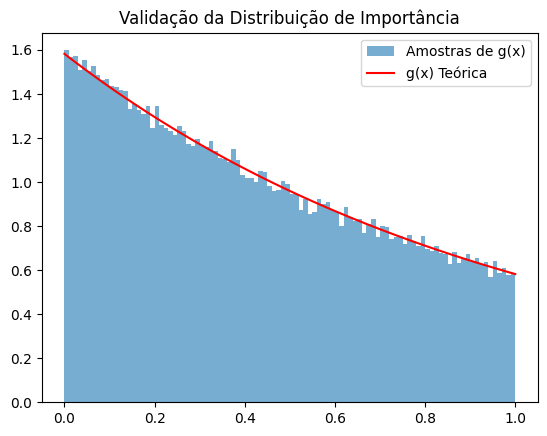

In [3]:
import numpy as np
import matplotlib.pyplot as plt

N = 100000

u = np.random.uniform(0, 1, N)

# Definição da constante A (Calculada analiticamente)
# A = 1 / (1 - e^-1)
A = 1 / (1 - np.exp(-1))

# Geração de amostras Y seguindo g(x) = A*e^-x (Método da Inversa)
# Derivado da CDF G(x) = (1 - e^-x) / (1 - e^-1)
y = -np.log(1 - u * (1 - np.exp(-1)))

# Funções f(y) e g(y) (Amostragem por Importância)
f_y = 1 / (1 + y)**2
# função de importância escolhida
g_y = A * np.exp(-y)

# Cálculo do Estimador (Razão f/g)
razoes = f_y / g_y
integral_estimada = np.mean(razoes)

# O valor da integral de 1/(1+x)^2 de 0 a 1 é 0.5
valor_real = 0.5
erro_absoluto = abs(integral_estimada - valor_real)

print(f"Valor Estimado (Importance Sampling): {integral_estimada:.6f}")
print(f"Valor Real Analítico: {valor_real:.6f}")
print(f"Erro Absoluto: {erro_absoluto:.6e}")

plt.hist(y, bins=100, density=True, alpha=0.6, label='Amostras de g(x)')
x_plot = np.linspace(0, 1, 100)
plt.plot(x_plot, A * np.exp(-x_plot), 'r', label='g(x) Teórica')
plt.title('Validação da Distribuição de Importância')
plt.legend()
plt.show()